## A. Data Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

### Step1: Load Data

In [2]:
PROJECT_ROOT = Path("/Users/nattawasprakinkij/Documents/SEMTM0044_2025_AYEAR_TEAM34")
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

PROTEIN_FILE = DATA_RAW / "ccle_proteomics_2020" / "protein_quant_current_normalized.csv"
SAMPLE_FILE  = DATA_RAW / "ccle_proteomics_2020" / "Table_S1_Sample_Information.xlsx"
MODEL_FILE   = DATA_RAW / "depmap_25Q2" / "Model.csv"

In [3]:
protein = pd.read_csv(PROTEIN_FILE)
sample  = pd.read_excel(SAMPLE_FILE, sheet_name="Sample_Information")
model   = pd.read_csv(MODEL_FILE)

print(f"protein matrix: {protein.shape[0]:>6,} rows × {protein.shape[1]:>4} cols")
print(f"sample info: {sample.shape[0]:>6,} rows × {sample.shape[1]:>4} cols")
print(f"DepMap model: {model.shape[0]:>6,} rows × {model.shape[1]:>4} cols")

protein matrix: 12,755 rows ×  426 cols
sample info:    388 rows ×    6 cols
DepMap model:  2,116 rows ×   49 cols


### Step2: Inspect structure

In [4]:
metadata_cols = [c for c in protein.columns if "_TenPx" not in c and not c.startswith("TenPx")]
peptide_cols  = [c for c in protein.columns if c.endswith("_Peptides")]
cell_cols     = [c for c in protein.columns if "_TenPx" in c and not c.endswith("_Peptides")]

print(f"Metadata columns: {len(metadata_cols)}  → {metadata_cols}")
print(f"Peptide columns: {len(peptide_cols)}  (42 TMT plexes)")
print(f"Cell line columns: {len(cell_cols)}")

Metadata columns: 6  → ['Protein_Id', 'Gene_Symbol', 'Description', 'Group_ID', 'Uniprot', 'Uniprot_Acc']
Peptide columns: 42  (42 TMT plexes)
Cell line columns: 378


### Step3: Z-score Distribution

In [5]:
values = protein[cell_cols].values.flatten()
values_nonan = values[~np.isnan(values)]

In [6]:
print(f"Total values: {len(values):>12,}")
print(f"Non-NaN: {len(values_nonan):>12,}  ({len(values_nonan)/len(values):.1%})")
print(f"NaN: {len(values)-len(values_nonan):>12,}  ({1-len(values_nonan)/len(values):.1%})")
print(f"\nMean = {values_nonan.mean():+.3f}")
print(f"Std = {values_nonan.std():.3f}")
print(f"Median = {np.median(values_nonan):+.3f}")
print(f"Min = {values_nonan.min():+.3f}")
print(f"Max = {values_nonan.max():+.3f}")

Total values:    4,821,390
Non-NaN:    3,472,434  (72.0%)
NaN:    1,348,956  (28.0%)

Mean = -0.030
Std = 0.967
Median = -0.043
Min = -23.050
Max = +12.813


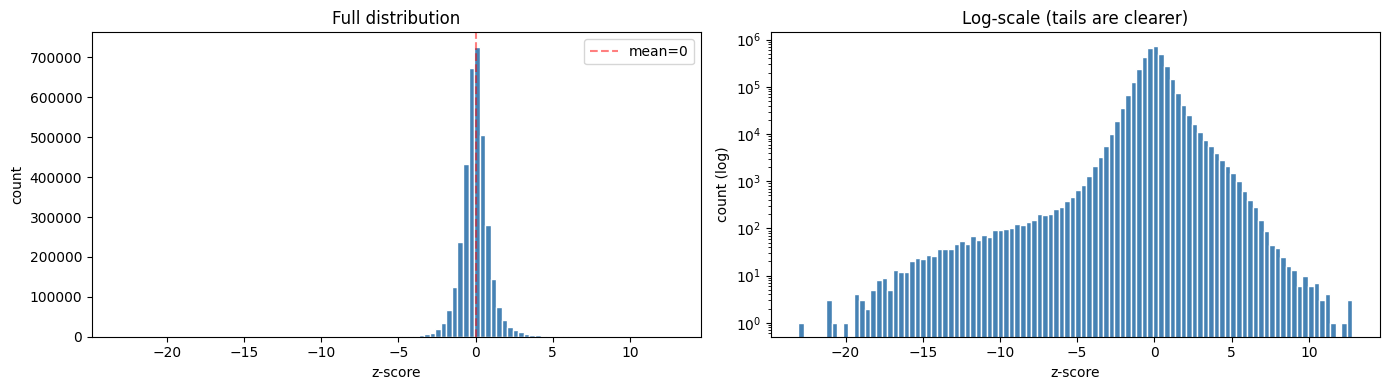

In [7]:
# Histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(values_nonan, bins=100, color="steelblue", edgecolor="white")
axes[0].axvline(0, color="red", linestyle="--", alpha=0.5, label="mean=0")
axes[0].set(xlabel="z-score", ylabel="count", title="Full distribution")
axes[0].legend()

axes[1].hist(values_nonan, bins=100, color="steelblue", edgecolor="white")
axes[1].set_yscale("log")
axes[1].set(xlabel="z-score", ylabel="count (log)", title="Log-scale (tails are clearer)")

plt.tight_layout()
plt.show()

Mean ≈ 0, std ≈ 0.97, so z-score normalization works.
28% NaN, which is high. Histogram is bell-shaped but with long tails
(min -23, max +12.8) which makes sense biologically since some proteins
have a huge dynamic range across tissues.

About 80% of values are in [-1, +1], so the meaningful signal sits in
the tails (|z| > 2 is roughly top/bottom 2.5%). NaN handling is going
to need attention later.

### Step4: NaN Pattern Analysis

In [8]:
nan_per_protein   = protein[cell_cols].isna().sum(axis=1)
nan_per_cellline  = protein[cell_cols].isna().sum(axis=0)

In [9]:
print("NaN per Protein:")
print(f"Mean: {nan_per_protein.mean():.0f}  ({nan_per_protein.mean()/len(cell_cols):.1%} of cells)")
print(f"Median: {nan_per_protein.median():.0f}")
print(f"Proteins with 0 NaN: {(nan_per_protein == 0).sum():>5,}  ({(nan_per_protein == 0).mean():.1%})")
print(f"Proteins with >50% NaN: {(nan_per_protein > len(cell_cols)/2).sum():>5,}")

print("\nNaN per Cell line:")
print(f"Mean: {nan_per_cellline.mean():.0f}  ({nan_per_cellline.mean()/len(protein):.1%} of proteins)")
print(f"Range: {nan_per_cellline.min():,} to {nan_per_cellline.max():,}")

NaN per Protein:
Mean: 106  (28.0% of cells)
Median: 27
Proteins with 0 NaN: 5,153  (40.4%)
Proteins with >50% NaN: 3,577

NaN per Cell line:
Mean: 3569  (28.0% of proteins)
Range: 2,194 to 4,564


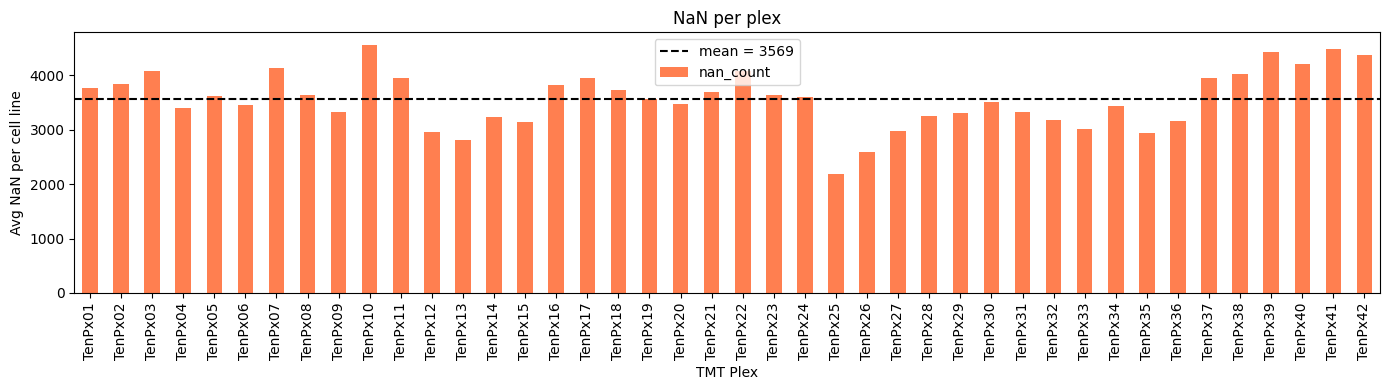

Plex that have the most NaN:
plex
TenPx10    4564.0
TenPx41    4489.0
TenPx39    4430.0
TenPx42    4379.0
TenPx40    4209.0
Name: nan_count, dtype: float64


In [10]:
plex_nan = pd.DataFrame({
    "cell_col": cell_cols,
    "nan_count": [nan_per_cellline[c] for c in cell_cols],
    "plex": [c.split("_")[-1] for c in cell_cols]
})
plex_summary = plex_nan.groupby("plex")["nan_count"].mean().sort_index()

plt.figure(figsize=(14, 4))
plex_summary.plot(kind="bar", color="coral")
plt.axhline(nan_per_cellline.mean(), color="black", linestyle="--", label=f"mean = {nan_per_cellline.mean():.0f}")
plt.xlabel("TMT Plex")
plt.ylabel("Avg NaN per cell line")
plt.title("NaN per plex")
plt.legend()
plt.tight_layout()
plt.show()

print("Plex that have the most NaN:")
print(plex_summary.nlargest(5))

- ~28% NaN overall but heavily skewed: median per-protein NaN = 27, mean = 106.
- 40% of proteins have zero NaN (core proteome), 28% have >50% NaN (hard to detect).
- Per cell line NaN ranges 2,194 — 4,564.
- Plex effect is real: TenPx10, 39, 40, 41, 42 have systematically more NaN.
  Late-plex clustering (39-42) suggests batch drift. TenPx10 looks like a
  one-off bad run.
- Implication: confidence scoring should account for plex-level batch effects,
  not treat all NaN the same.